In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

plt.style.use('ggplot')

pd.set_option("display.max_columns", None)

In [2]:
df = pd.read_csv("../data/processed/glassdoor_jobs_cleaned.csv")

df.head()

,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,Type of ownership,Industry,Sector,Revenue,Competitors,Min Salary,Max Salary,Average Salary,Company Age,State
0,Data Scientist,53-91,"Data Scientist\nLocation: Albuquerque, NM\nEdu...",3.8,Tecolote Research,"Albuquerque, NM","Goleta, CA",501 to 1000 employees,1973,Company - Private,Aerospace & Defense,Aerospace & Defense,$50 to $100 million (USD),-1,53.0,91.0,72.0,53.0,NM
1,Healthcare Data Scientist,63-112,What You Will Do:\n\nI. General Summary\n\nThe...,3.4,University of Maryland Medical System,"Linthicum, MD","Baltimore, MD",10000+ employees,1984,Other Organization,Health Care Services & Hospitals,Health Care,$2 to $5 billion (USD),-1,63.0,112.0,87.5,42.0,MD
2,Data Scientist,80-90,"KnowBe4, Inc. is a high growth information sec...",4.8,KnowBe4,"Clearwater, FL","Clearwater, FL",501 to 1000 employees,2010,Company - Private,Security Services,Business Services,$100 to $500 million (USD),-1,80.0,90.0,85.0,16.0,FL
3,Data Scientist,56-97,*Organization and Job ID**\nJob ID: 310709\n\n...,3.8,PNNL,"Richland, WA","Richland, WA",1001 to 5000 employees,1965,Government,Energy,"Oil, Gas, Energy & Utilities",$500 million to $1 billion (USD),"Oak Ridge National Laboratory, National Renewa...",56.0,97.0,76.5,61.0,WA
4,Data Scientist,86-143,Data Scientist\nAffinity Solutions / Marketing...,2.9,Affinity Solutions,"New York, NY","New York, NY",51 to 200 employees,1998,Company - Private,Advertising & Marketing,Business Services,Unknown / Non-Applicable,"Commerce Signals, Cardlytics, Yodlee",86.0,143.0,114.5,28.0,NY


In [3]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 956
Columns: 19


📊 Visualization 1: Salary Distribution
Objective

Understand how salaries are distributed.

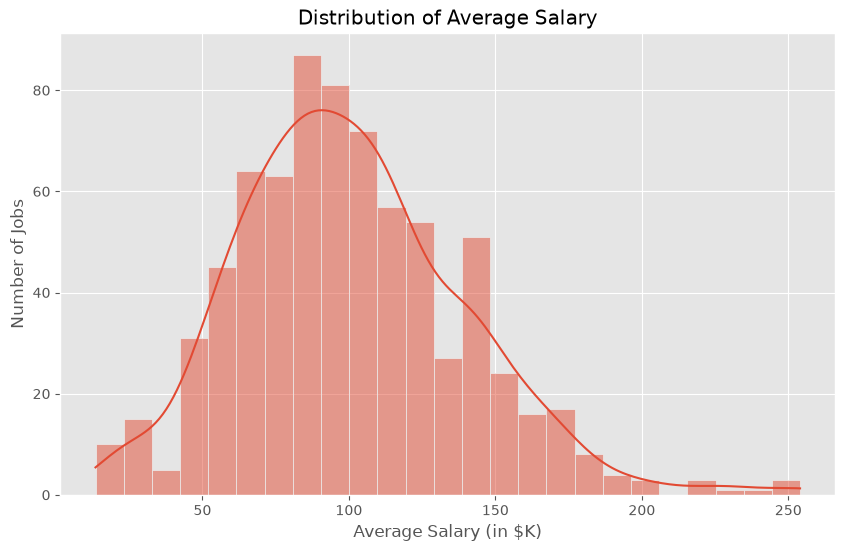

In [ ]:
plt.figure(figsize=(10,6))

sns.histplot(df["Average Salary"], bins=25, kde=True) # pyright: ignore[reportArgumentType]

plt.title("Distribution of Average Salary")
plt.xlabel("Average Salary (in $K)")
plt.ylabel("Number of Jobs")

plt.show()

### Observation

- Most salaries fall between **$60K and $120K**.
- Very high salaries are relatively rare.
- The distribution is slightly right-skewed, indicating a smaller number of high-paying roles.

📊 Visualization 2: Average Salary by Job Title

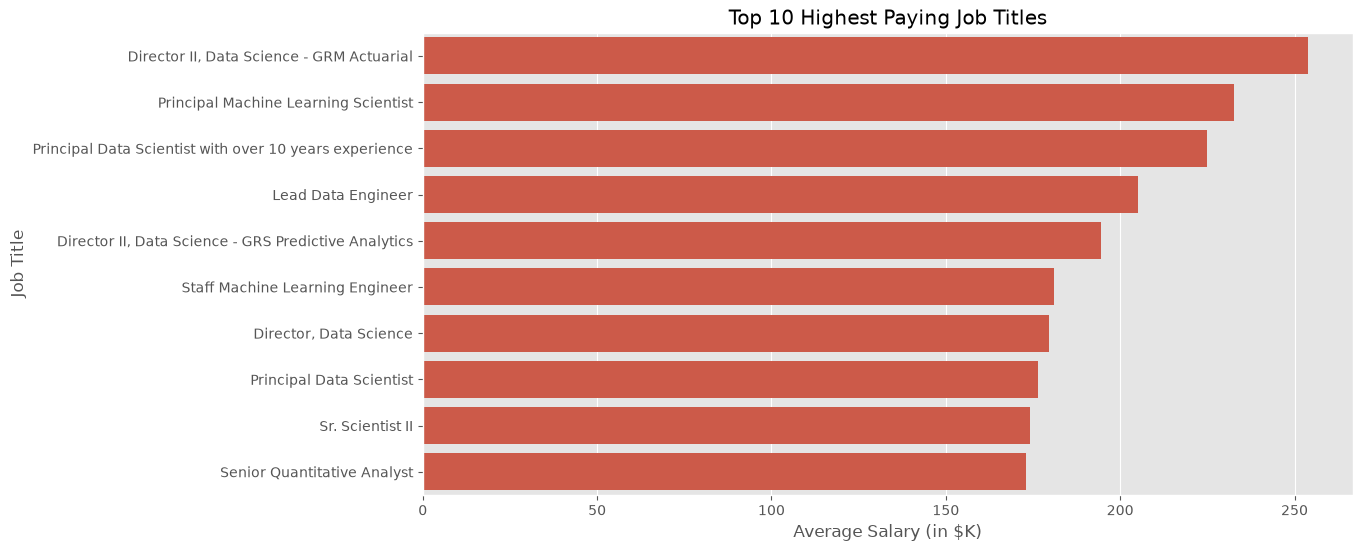

In [5]:
top_jobs = df.groupby("Job Title")["Average Salary"].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_jobs.values,
    y=top_jobs.index
)

plt.title("Top 10 Highest Paying Job Titles")
plt.xlabel("Average Salary (in $K)")
plt.ylabel("Job Title")

plt.show()

### Observation

- Specialized technical roles tend to receive higher salaries.
- Salary varies significantly across different job positions.

📊 Visualization 3: Salary by Company Size

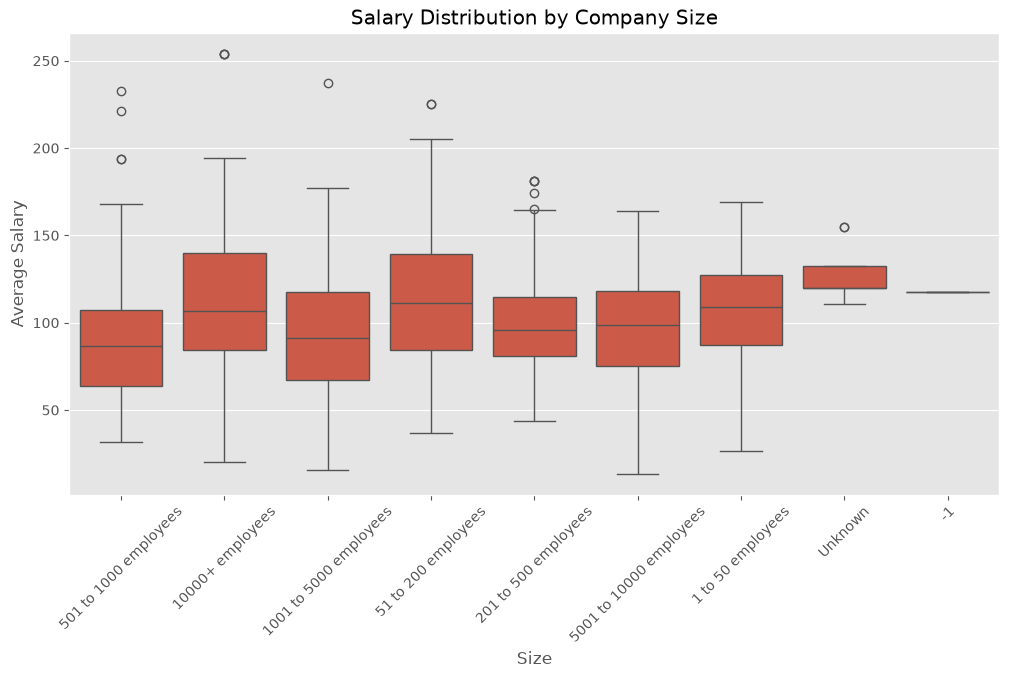

In [6]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data=df,
    x="Size",
    y="Average Salary"
)

plt.xticks(rotation=45)

plt.title("Salary Distribution by Company Size")

plt.show()

### Observation

- Medium and large companies generally offer higher salaries.
- Startups exhibit greater salary variability.

📊 Visualization 4: Average Salary by State

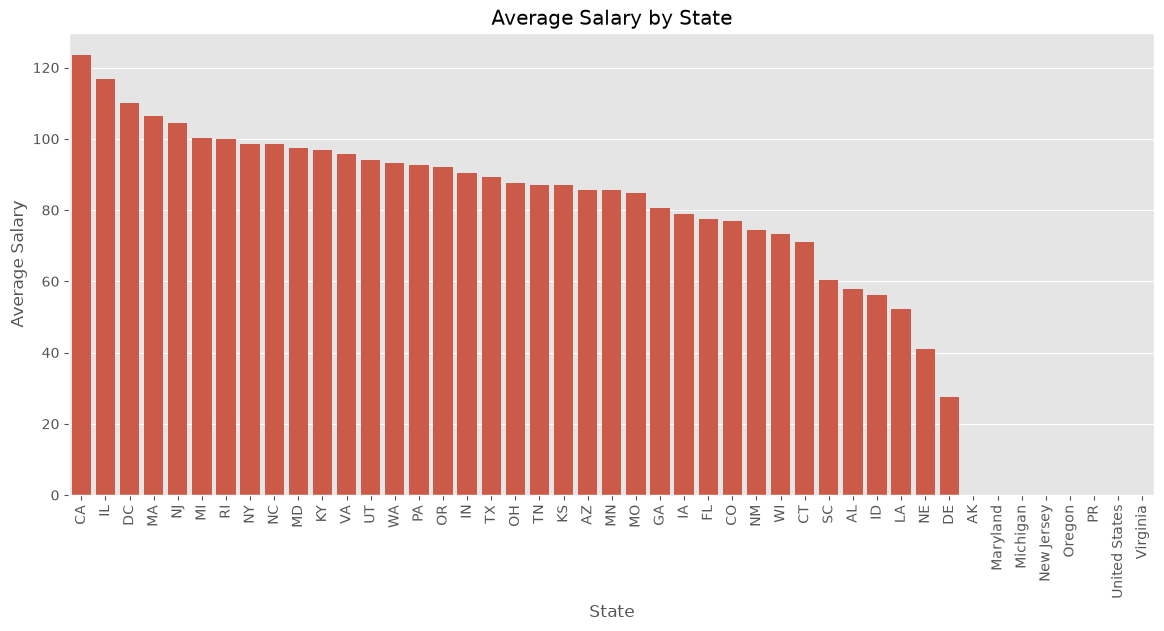

In [7]:
state_salary = df.groupby("State")["Average Salary"].mean().sort_values(ascending=False)

plt.figure(figsize=(14,6))

sns.barplot(
    x=state_salary.index,
    y=state_salary.values
)

plt.xticks(rotation=90)

plt.title("Average Salary by State")

plt.ylabel("Average Salary")

plt.show()

### Observation

- Salaries vary considerably across different states.
- States with major technology hubs generally offer higher compensation.

📊 Visualization 5: Correlation Heatmap

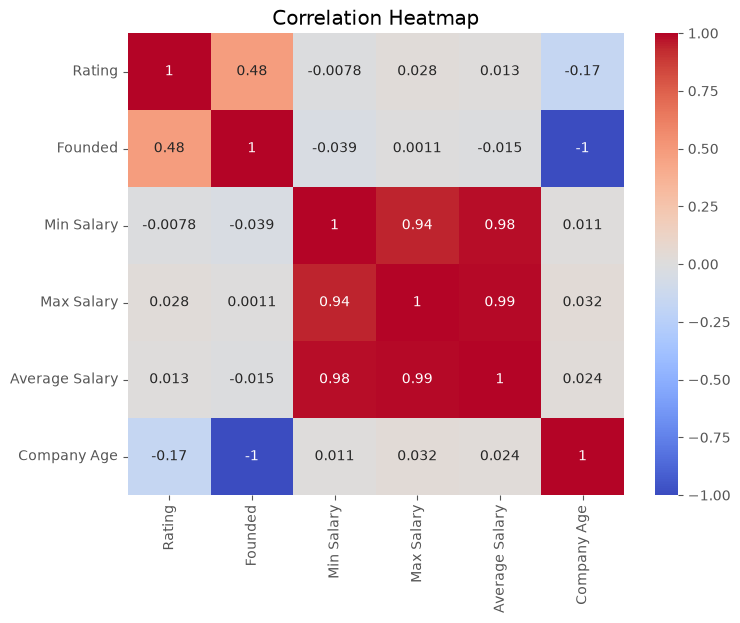

In [8]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

### Observation

- Average Salary is strongly correlated with Min Salary and Max Salary.
- Company Age shows little correlation with salary.

📊 Visualization 6: Top Industries

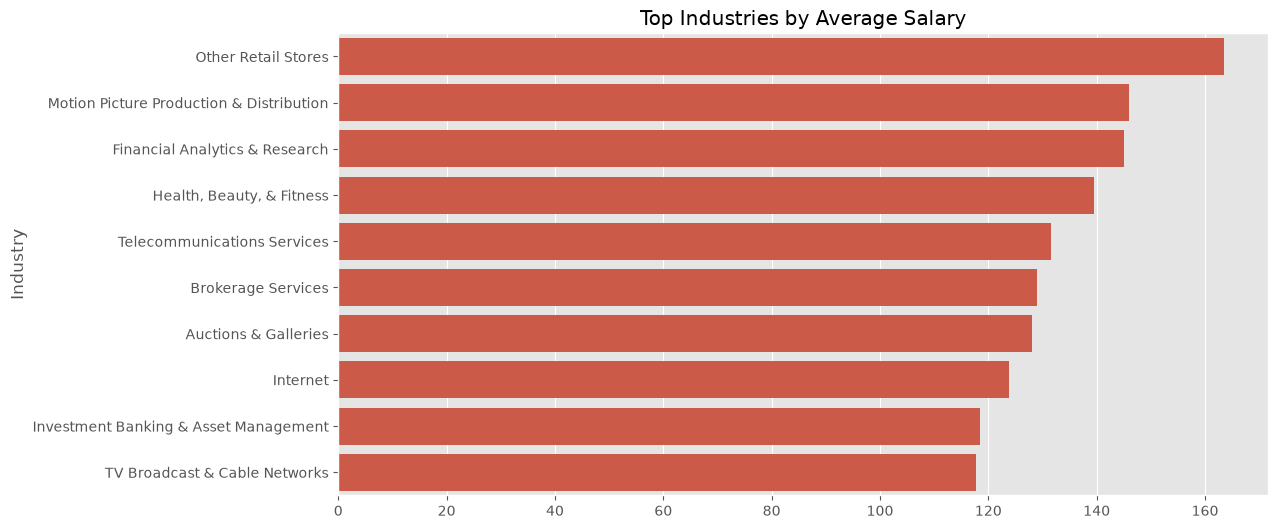

In [9]:
industry_salary = (
    df.groupby("Industry")["Average Salary"]
      .mean()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=industry_salary.values,
    y=industry_salary.index
)

plt.title("Top Industries by Average Salary")

plt.show()

### Observation

- Technology-oriented industries generally provide higher salaries.
- Industry is an important factor affecting compensation.

📊 Visualization 7: Company Rating vs Salary

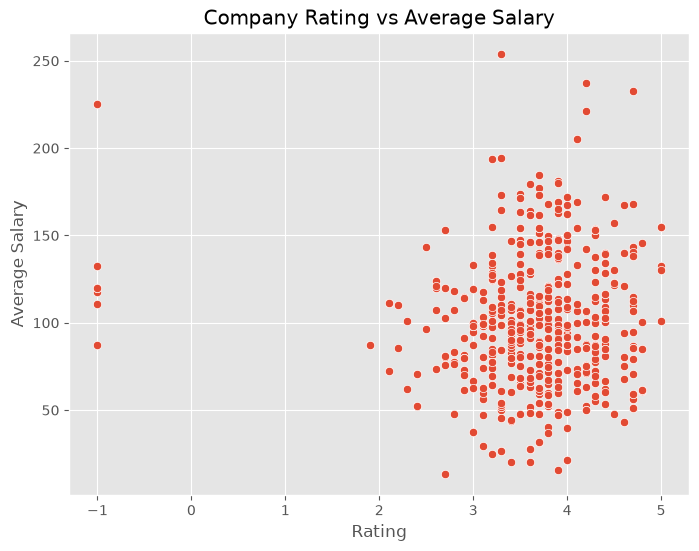

In [10]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="Rating",
    y="Average Salary"
)

plt.title("Company Rating vs Average Salary")

plt.show()

### Observation

- Company ratings do not show a strong linear relationship with salary.
- Highly rated companies are not always the highest paying.

📊 Visualization 8: Sector-wise Salary

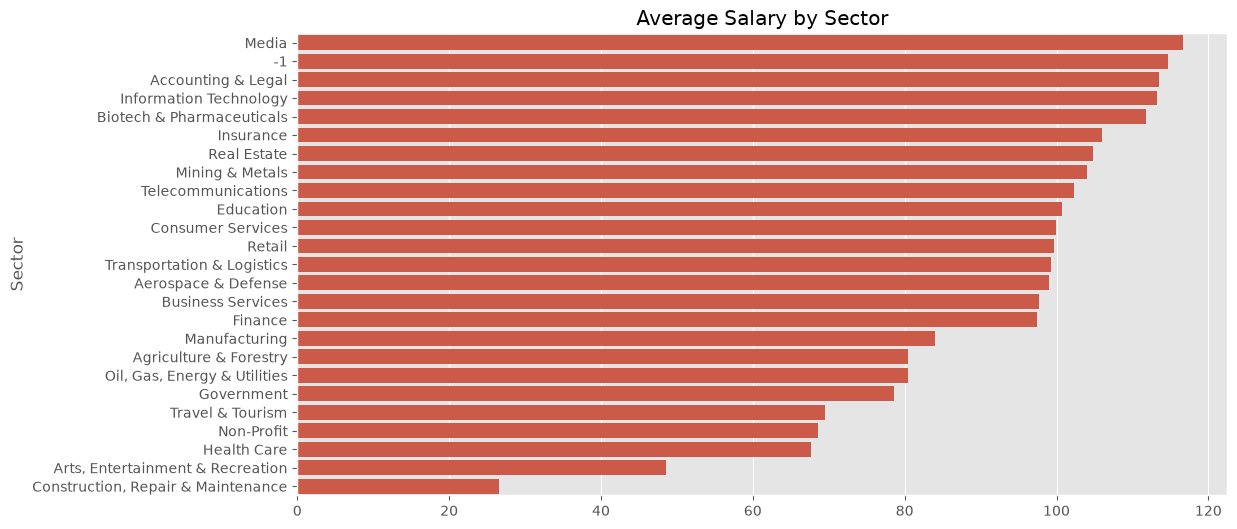

In [11]:
sector_salary = (
    df.groupby("Sector")["Average Salary"]
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=sector_salary.values,
    y=sector_salary.index
)

plt.title("Average Salary by Sector")

plt.show()

### Observation

- Certain sectors consistently provide higher salaries.
- Sector is a useful feature for salary prediction.

Top 10 Highest Paying Companies

In [12]:
top_company = (
    df.groupby("Company Name")["Average Salary"]
      .mean()
      .sort_values(ascending=False)
      .head(10)
)

top_company

Company Name
Gallup                      237.5
Sage Intacct                232.5
CA-One Tech Cloud           225.0
Grand Rounds                221.5
Credit Sesame               205.0
The Climate Corporation     194.0
Grainger                    179.5
Samsung Research America    177.0
Nektar Therapeutics         174.0
DTCC                        173.0
Name: Average Salary, dtype: float64

Highest Paying Locations

In [13]:
df.groupby("Location")["Average Salary"].mean().sort_values(ascending=False).head(10)

Location
Bellevue, WA         184.500000
Lake Forest, IL      179.500000
Mountain View, CA    177.187500
Novato, CA           168.000000
Burbank, CA          164.000000
Emeryville, CA       153.000000
Newark, NJ           146.000000
Fort Lee, NJ         145.666667
Jersey City, NJ      144.750000
Brisbane, CA         143.500000
Name: Average Salary, dtype: float64

Highest Paying Industries

In [14]:
df.groupby("Industry")["Average Salary"].mean().sort_values(ascending=False).head(10)

Industry
Other Retail Stores                         163.500000
Motion Picture Production & Distribution    146.000000
Financial Analytics & Research              145.125000
Health, Beauty, & Fitness                   139.500000
Telecommunications Services                 131.500000
Brokerage Services                          129.000000
Auctions & Galleries                        128.000000
Internet                                    123.810345
Investment Banking & Asset Management       118.400000
TV Broadcast & Cable Networks               117.750000
Name: Average Salary, dtype: float64

# Business Insights

1. Salary differs significantly across job titles.
2. Larger companies generally pay more.
3. Geographic location strongly influences salary.
4. Industry and sector impact salary levels.
5. Company ratings have little effect on salary.
6. Salary prediction should include:
   - Job Title
   - Location
   - Industry
   - Sector
   - Company Size
   - Company Age

# Conclusion

The exploratory analysis reveals that salary is influenced by multiple factors including job title, company size, industry, and location.

These insights support the development of a machine learning model capable of predicting salaries with reasonable accuracy.

In [15]:
plt.savefig("../images/salary_distribution.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>